In [31]:

from __future__ import annotations

import colorsys
import difflib
import re
import sys
import textwrap
from collections import defaultdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

_ANALYSIS_DIR = str(Path("./").resolve())   # workload_generation/analysis
if _ANALYSIS_DIR not in sys.path:
    sys.path.insert(0, _ANALYSIS_DIR)

from analysis import resolve_workload_path, load_plans_file                       # noqa: E402
from loader.workload_analysis import dags_from_plan_bundle, canonical_plan_graph_signature  # noqa: E402
from workload_generation.shared.sql_features import query_features                 # noqa: E402

import numpy as np
import networkx as nx
from networkx.drawing.nx_pydot import to_pydot
import pydot
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle

FIGURES_DIR = Path("./results/figures").resolve().parent

# ---------------------------------------------------------------------
# Palette (muted, paper-friendly)
# ---------------------------------------------------------------------
INK = "#1f2937"
MUTED = "#373a3f"
COL_A = "#4b7a83"   # muted teal
COL_B = "#a15574"   # muted mauve
COL_SHARED = "#1f2937"
BG_A = "#eef2f2"
BG_B = "#f5eef1"

ANSI_BLUE = "#0225C7"
ANSI_MAGENTA = "#B02DB0"
ANSI_GREEN = "#008400"
ANSI_RED = "#C91B00"
ANSI_CYAN = "#00868A"

KEYWORDS = {
    "select", "distinct", "as", "from", "where", "and", "or", "not", "in",
    "between", "exists", "group", "by", "order", "limit", "with", "on",
    "join", "inner", "left", "is", "null", "interval", "day", "asc", "desc",
    "case", "when", "then", "else", "end",
}
FUNCTIONS = {"count", "sum", "avg", "min", "max", "cast", "substr", "rank"}

CAT_COLOR = {
    "scan": "#b45309", "join": "#4338ca", "aggregate": "#0f766e",
    "sort": "#7e22ce", "output": "#334155", "project": "#475569",
    "filter": "#c2410c", "misc": "#78716c",
}
CAT_MERGE_LABEL = {
    "aggregate": "Aggregate",
    "sort": "Sort",
}

TOKEN_RE = re.compile(r"'[^']*'|\d+\.\d+|\d+|[A-Za-z_][A-Za-z0-9_]*|\s+|.", re.S)


def _categorize(op_name: str) -> str:
    if op_name in ("TableScan", "ScanFilter", "ScanFilterProject"):
        return "scan"
    if "Join" in op_name:
        return "join"
    if op_name == "Aggregate":
        return "aggregate"
    if op_name in ("TopN", "TopNPartial"):
        return "sort"
    if op_name == "Output":
        return "output"
    if op_name == "Project":
        return "project"
    if op_name in ("LocalExchange", "RemoteSource"):
        return "exchange"
    if "Filter" in op_name:
        return "filter"
    return "misc"


def _classify_token(tok: str, tables: set) -> Optional[str]:
    if tok[0] == "'":
        return ANSI_GREEN
    if re.match(r"^\d+(\.\d+)?$", tok):
        return ANSI_RED
    if tok.isspace():
        return None
    low = tok.lower()
    if low in KEYWORDS:
        return ANSI_BLUE
    if low in FUNCTIONS:
        return ANSI_MAGENTA
    if low in tables:
        return ANSI_CYAN
    if re.match(r"^[A-Za-z_][A-Za-z0-9_]*$", tok):
        return INK
    return MUTED


def _wrap_sql(sql_text: str, width: int, max_indent: int) -> List[str]:
    """Wrap each SQL line to at most `width` characters, keeping the
    original line's leading indent (capped at `max_indent`) on wrapped
    continuation lines so nested clauses stay visually nested rather
    than snapping back to the left margin."""
    out_lines = []
    for raw_line in sql_text.split("\n"):
        stripped = raw_line.rstrip()
        if not stripped.strip():
            continue
        indent = len(stripped) - len(stripped.lstrip(" "))
        capped = min(indent, max_indent)
        lead = " " * capped
        body = stripped[indent:]
        avail = max(1, width - capped)
        if len(body) <= avail:
            out_lines.append(lead + body)
        else:
            wrapped = textwrap.wrap(
                body, width=avail,
                initial_indent=lead, subsequent_indent=lead + "  ",
                break_long_words=False, break_on_hyphens=False,
            )
            out_lines.extend(wrapped)
    return out_lines


def _collapse_dag(dag: dict) -> Tuple[Dict[str, Tuple[str, str]], List[Tuple[str, str]]]:
    """Splice out exchange plumbing + merge same-category Aggregate/Sort
    chains. Returns (nodes: id -> (label, category), edges: [(parent, child)])."""
    nodes = dag["nodes"]
    children: Dict[str, List[str]] = defaultdict(list)
    parents: Dict[str, List[str]] = defaultdict(list)
    for e in dag["edges"]:
        p, c = e[0], e[1]
        children[p].append(c)
        parents[c].append(p)

    alive = set(nodes.keys())
    cat = {nid: _categorize(nodes[nid]["name"]) for nid in nodes}

    # 1. splice out pure-exchange nodes with exactly one parent and one child
    changed = True
    while changed:
        changed = False
        for nid in list(alive):
            if nid not in alive:
                continue
            if cat.get(nid) != "exchange":
                continue
            ps = [p for p in parents.get(nid, []) if p in alive]
            cs = [c for c in children.get(nid, []) if c in alive]
            if len(ps) == 1 and len(cs) == 1:
                p, c = ps[0], cs[0]
                children[p] = [c if x == nid else x for x in children[p]]
                parents[c] = [p if x == nid else x for x in parents[c]]
                alive.discard(nid)
                changed = True

    # 2. merge consecutive same-category aggregate/sort chains (1-in-1-out)
    def broad(nid):
        return cat[nid] if cat[nid] in ("aggregate", "sort") else None

    changed = True
    while changed:
        changed = False
        for nid in list(alive):
            if nid not in alive:
                continue
            bc = broad(nid)
            if bc is None:
                continue
            cs = [c for c in children.get(nid, []) if c in alive]
            if len(cs) != 1:
                continue
            c = cs[0]
            if broad(c) != bc:
                continue
            if len([p for p in parents.get(c, []) if p in alive]) != 1:
                continue
            grandchildren = [g for g in children.get(c, []) if g in alive]
            children[nid] = grandchildren
            for g in grandchildren:
                parents[g] = [nid if x == c else x for x in parents[g]]
            alive.discard(c)
            changed = True

    out_nodes: Dict[str, Tuple[str, str]] = {}
    for nid in alive:
        c = cat[nid]
        label = CAT_MERGE_LABEL.get(c, nodes[nid]["name"])
        out_nodes[nid] = (label, c)
    out_edges = [(p, c) for p in alive for c in children.get(p, []) if c in alive]
    return out_nodes, out_edges


def _table_jaccard(tables_a, tables_b) -> float:
    a, b = {t.lower() for t in tables_a}, {t.lower() for t in tables_b}
    if not a and not b:
        return 1.0
    return len(a & b) / len(a | b)


def list_collision_pairs(workload: str = "tpcds", workload_root: Optional[str] = None):
    import pandas as pd
    from itertools import combinations

    wpath = (resolve_workload_path(workload, workload_root=workload_root)
             if workload_root else resolve_workload_path(workload))
    bundle = load_plans_file(wpath)
    if bundle is None:
        raise ValueError(f"No plans.json for workload '{workload}' -- capture plans first.")
    dags = dags_from_plan_bundle(bundle)
    plans = bundle["plans"]

    sig = {q: canonical_plan_graph_signature(dags[q]) for q in dags}
    groups: Dict[str, List[str]] = defaultdict(list)
    for q, s in sig.items():
        groups[s].append(q)

    feat = {q: query_features(plans[q]["sql"]) for q in dags}
    rows = []
    for s, qs in groups.items():
        if len(qs) < 2:
            continue
        for qa, qb in combinations(sorted(qs), 2):
            tj = _table_jaccard(feat[qa].get("tables", []), feat[qb].get("tables", []))
            ts = difflib.SequenceMatcher(
                None,
                " ".join(plans[qa]["sql"].lower().split()),
                " ".join(plans[qb]["sql"].lower().split()),
            ).ratio()
            rows.append({
                "query_a": qa, "query_b": qb,
                "table_jaccard": round(tj, 3), "text_similarity": round(ts, 3),
                "surprise_score": round(((1 - tj) + (1 - ts)) / 2, 3),
                "full_plan_nodes": len(dags[qa]["nodes"]),
            })
    return pd.DataFrame(rows).sort_values("surprise_score", ascending=False).reset_index(drop=True)


def make_plan_collision_figure(
    query_a: str,
    query_b: str,
    *,
    workload: str = "tpcds",
    workload_root: Optional[str] = None,
    preview_lines: int = 10,
    out_name: str = "plan_collision_example",
    out_dir: Optional[Path] = None,
    title: Optional[str] = None,
    label_a: Optional[str] = None,
    label_b: Optional[str] = None,
    show: bool = True,
    # -----------------------------------------------------------
    # Size/layout knobs -- override any of these instead of hand-
    # editing constants in the function body. See the slider cell
    # below for a live UI over all of these.
    # -----------------------------------------------------------
    fig_w: float = 7.5,
    sql_box_w: float = 3.5,
    sql_box_gap: float = 0.15,
    sql_font: float = 8.6,
    sql_line_pitch: float = 0.15,
    arrow_gap: float = 0.5,
    plan_header_h: float = 0.62,
    plan_caption_h: float = 0.48,
    panel_w_floor: float = 5.6,
    graph_side_pad: float = 0.4,
    max_fill_scale: float = 2.0,
    node_box_scale: float = 1.0,
    graph_ranksep: float = 0.25,
    graph_nodesep: float = 0.25,
    converge_spread: float = 1.4,
    # -----------------------------------------------------------
    # SQL text opacity + the remaining (non-node) font sizes.
    # -----------------------------------------------------------
    sql_text_alpha: float = 1.0,
    sql_fade_height: float = 0.9,
    sql_title_font: float = 12.0,
    panel_title_font: float = 10.0,
    caption_font: float = 13.0,
    # -----------------------------------------------------------
    # Color intensity -- color_vibrancy boosts saturation on the SQL
    # syntax-highlight colors, the two query accent colors (and their
    # backgrounds), and the DAG node category colors. node_fill_mute
    # is how much white gets blended into a node box's fill (lower =
    # more saturated fill); the node's border always stays full color.
    # -----------------------------------------------------------
    color_vibrancy: float = 1.35,
    node_fill_mute: float = 0.55,
):
    """Build the headline "two queries, one plan" figure and save it as
    <out_dir>/<out_name>.png and .pdf. Returns the saved PNG path.

    Raises ValueError if query_a/query_b don't share a plans.json entry or
    don't actually compile to the same plan (canonical_plan_graph_signature).
    """
    wpath = (resolve_workload_path(workload, workload_root=workload_root)
             if workload_root else resolve_workload_path(workload))
    bundle = load_plans_file(wpath)
    if bundle is None:
        raise ValueError(f"No plans.json for workload '{workload}' -- capture plans first.")
    dags = dags_from_plan_bundle(bundle)
    if query_a not in dags or query_b not in dags:
        missing = [q for q in (query_a, query_b) if q not in dags]
        raise ValueError(f"Query name(s) not found in {workload}'s plans.json: {missing}")

    dag_a, dag_b = dags[query_a], dags[query_b]
    if canonical_plan_graph_signature(dag_a) != canonical_plan_graph_signature(dag_b):
        raise ValueError(
            f"{query_a} and {query_b} do NOT compile to the same Trino plan "
            "(canonical_plan_graph_signature differs) -- pick a genuine collision pair."
        )
    full_n_nodes, full_n_edges = len(dag_a["nodes"]), len(dag_a["edges"])

    plans = bundle["plans"]
    sql_a, sql_b = plans[query_a]["sql"], plans[query_b]["sql"]
    feat_a, feat_b = query_features(sql_a), query_features(sql_b)
    tables_a, tables_b = feat_a.get("tables", []), feat_b.get("tables", [])
    tbl_jaccard = _table_jaccard(tables_a, tables_b)
    text_sim = difflib.SequenceMatcher(
        None, " ".join(sql_a.lower().split()), " ".join(sql_b.lower().split())
    ).ratio()
    all_tables = {t.lower() for t in tables_a} | {t.lower() for t in tables_b}

    def classify(tok):
        return _classify_token(tok, all_tables)

    def _boost(hex_color, factor):
        """Push a color's saturation up by `factor` (1.0 = unchanged),
        clamped so it never blows out to a garish oversaturated result."""
        r, g, b = to_rgba(hex_color)[:3]
        h, s, v = colorsys.rgb_to_hsv(r, g, b)
        s = min(1.0, s * factor)
        v = min(1.0, v * (1.0 + (factor - 1.0) * 0.12))
        return colorsys.hsv_to_rgb(h, s, v)

    col_a_v = _boost(COL_A, color_vibrancy)
    col_b_v = _boost(COL_B, color_vibrancy)
    bg_a_v = _boost(BG_A, color_vibrancy)
    bg_b_v = _boost(BG_B, color_vibrancy)

    n_lines = preview_lines

    # ---------------------------------------------------------------
    # Collapsed plan DAG -> Graphviz `dot` layout
    # ---------------------------------------------------------------
    node_defs, edge_defs = _collapse_dag(dag_a)
    G = nx.DiGraph()
    G.add_nodes_from(node_defs)
    G.add_edges_from(edge_defs)

    P = to_pydot(G)
    P.set_rankdir("TB")
    P.set_ranksep(str(graph_ranksep))
    P.set_nodesep(str(graph_nodesep))
    P.set_splines("spline")
    P.set_prog("dot")
    dot_src = P.create_dot().decode("utf-8")
    (pg,) = pydot.graph_from_dot_data(dot_src)
    raw_pos = {}
    for n in pg.get_nodes():
        nm = n.get_name().strip('"')
        if nm in G.nodes and n.get_pos():
            x, y = n.get_pos().strip('"').split(",")
            raw_pos[nm] = (float(x), float(y))
    xs = [p[0] for p in raw_pos.values()]
    ys = [p[1] for p in raw_pos.values()]
    X0, X1 = min(xs), max(xs)
    Y0, Y1 = min(ys), max(ys)

    # auto-scale graph panel to the collapsed node/rank bounding box, clamped
    # to a sane paper-figure range so this "just works" for small or large
    # pairs without any manual tuning per query
    NATURAL_GRAPH_W = min(9.2, max(0.0025, 0.0055 * (X1 - X0) + 1.6))
    NATURAL_GRAPH_H = min(6.0, max(0.002, 0.0055 * (Y1 - Y0) + 0.3))

    # The panel has a minimum width (panel_w_floor) regardless of how small
    # the collapsed DAG is, so a small DAG at its "natural" size would leave
    # a big empty margin inside the panel. Instead, zoom the whole diagram
    # (positions, node boxes, fonts, arrows) up -- uniformly, preserving its
    # aspect ratio -- so it actually fills the panel it's drawn in.
    # node_box_scale is an independent knob on top of that: it only grows
    # the node boxes/fonts/arrows, not the panel or the layout spacing.
    fill_scale = min(max_fill_scale, max(1.0, (panel_w_floor - graph_side_pad) / NATURAL_GRAPH_W))
    GRAPH_W = NATURAL_GRAPH_W * fill_scale
    GRAPH_H = NATURAL_GRAPH_H * fill_scale
    NODE_R = 0.19

    # ---------------------------------------------------------------
    # Figure geometry (derived additively so nothing can overlap)
    # ---------------------------------------------------------------
    FIG_W = fig_w
    TOP_MARGIN = 0.05
    SQL_FONT = sql_font
    LINE_PITCH = sql_line_pitch
    SQL_HEADER_H = 0.38
    SQL_PAD_BOTTOM = 0.18
    BOX_H = SQL_HEADER_H + n_lines * LINE_PITCH + SQL_PAD_BOTTOM
    ARROW_GAP = arrow_gap

    PLAN_HEADER_H = plan_header_h
    PLAN_CAPTION_H = plan_caption_h
    PLAN_BOX_H = PLAN_HEADER_H + GRAPH_H + PLAN_CAPTION_H + 0.25
    BOTTOM_MARGIN = 0.07

    FIG_H = TOP_MARGIN + BOX_H + ARROW_GAP + PLAN_BOX_H + BOTTOM_MARGIN

    fig = plt.figure(figsize=(FIG_W, FIG_H))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, FIG_W)
    ax.set_ylim(0, FIG_H)
    ax.axis("off")

    # ---------------------------------------------------------------
    # SQL preview text -- wrapped to the *actual* pixel width of the
    # SQL box (sql_box_w at the current sql_font), not a fixed character
    # count, so text can never spill past the box edge no matter how
    # sql_box_w/sql_font are set. Continuation lines keep the original
    # line's indent so nested clauses still read as nested.
    # ---------------------------------------------------------------
    TEXT_PAD = 0.17  # matches the left inset used when drawing SQL tokens below
    _probe = ax.text(-100, -100, "M" * 40, fontsize=SQL_FONT, family="monospace")
    fig.canvas.draw()
    _bbox = _probe.get_window_extent(renderer=fig.canvas.get_renderer())
    _bbox_data = ax.transData.inverted().transform(_bbox)
    CHAR_W = (_bbox_data[1][0] - _bbox_data[0][0]) / 40.0
    _probe.remove()

    max_text_w = max(0.5, sql_box_w - 2 * TEXT_PAD)
    wrap_width = max(10, int(max_text_w / CHAR_W * 0.97))
    max_indent = min(6, max(0, wrap_width // 4))

    lines_a_full = _wrap_sql(sql_a, wrap_width, max_indent)
    lines_b_full = _wrap_sql(sql_b, wrap_width, max_indent)
    lines_a = lines_a_full[:preview_lines]
    lines_b = lines_b_full[:preview_lines]
    trunc_a = len(lines_a_full) > preview_lines
    trunc_b = len(lines_b_full) > preview_lines

    # ---------------------------------------------------------------
    # Title / claim
    # ---------------------------------------------------------------
    title = title or "Two TPC-DS queries, One Trino plan"
    label_a = label_a or f"Query {query_a[1:]}"
    label_b = label_b or f"Query {query_b[1:]}"

    # ---------------------------------------------------------------
    # SQL boxes
    # ---------------------------------------------------------------
    BOX_TOP = FIG_H - TOP_MARGIN
    BOX_W = sql_box_w
    GAP = sql_box_gap
    LEFT_X = (FIG_W - 2 * BOX_W - GAP) / 2
    RIGHT_X = LEFT_X + BOX_W + GAP

    FADE_H = sql_fade_height

    def add_fade(x, y_bottom, width, height, color):
        rgb = to_rgba(color)[:3]
        grad = np.zeros((256, 1, 4))
        grad[:, 0, 0], grad[:, 0, 1], grad[:, 0, 2] = rgb
        grad[:, 0, 3] = np.linspace(1, 0, 256) ** 0.5
        ax.imshow(grad, extent=(x, x + width, y_bottom, y_bottom + height),
                  origin="lower", aspect="auto", zorder=4, interpolation="bilinear")

    def sql_box(x, title_, subtitle_, lines, color, bg, truncated):
        box = FancyBboxPatch(
            (x, BOX_TOP - BOX_H), BOX_W, BOX_H,
            boxstyle="round,pad=0.02,rounding_size=0.1",
            linewidth=1.3, edgecolor=color, facecolor=bg, zorder=2,
        )
        ax.add_patch(box)
        ax.text(x + 0.16, BOX_TOP - 0.10, title_, fontsize=sql_title_font, fontweight="bold",
                 color=color, family="sans-serif", va="top")
        y = BOX_TOP - SQL_HEADER_H
        text_x0 = x + TEXT_PAD
        for ln in lines:
            xc = text_x0
            for tok in TOKEN_RE.findall(ln):
                col = classify(tok)
                if col is not None and not tok.isspace():
                    ax.text(xc, y, tok, fontsize=SQL_FONT, color=_boost(col, color_vibrancy),
                             family="monospace", va="top", ha="left", zorder=3,
                             alpha=sql_text_alpha)
                xc += CHAR_W * len(tok)
            y -= LINE_PITCH
        if truncated:
            add_fade(x + 0.02, BOX_TOP - BOX_H + 0.02, BOX_W - 0.04, FADE_H, bg)
            ax.text(x + BOX_W / 2, BOX_TOP - BOX_H + FADE_H * 0.55, "⋯",
                     ha="center", va="center", fontsize=sql_title_font, color="black",
                     family="sans-serif", zorder=5)
        return x + BOX_W / 2, BOX_TOP - BOX_H

    qa_bottom_x, qa_bottom_y = sql_box(
        LEFT_X, label_a, "verbatim SQL preview", lines_a, col_a_v, bg_a_v, trunc_a,
    )
    qb_bottom_x, qb_bottom_y = sql_box(
        RIGHT_X, label_b, "verbatim SQL preview", lines_b, col_b_v, bg_b_v, trunc_b,
    )

    # ---------------------------------------------------------------
    # Plan panel
    # ---------------------------------------------------------------
    PLAN_BOX_W = max(panel_w_floor, GRAPH_W + graph_side_pad)
    plan_box_x = FIG_W / 2 - PLAN_BOX_W / 2
    plan_box_bottom = BOTTOM_MARGIN
    plan_box_top = plan_box_bottom + PLAN_BOX_H
    plan_box = FancyBboxPatch(
        (plan_box_x, plan_box_bottom), PLAN_BOX_W, PLAN_BOX_H,
        boxstyle="round,pad=0.02,rounding_size=0.1",
        linewidth=1.4, edgecolor=COL_SHARED, facecolor="#f8fafc", zorder=2,
    )
    ax.add_patch(plan_box)
    ax.text(FIG_W / 2, plan_box_top - 0.2,
             "Query Execution Plan (Operator DAG)",
             ha="center", fontsize=panel_title_font, fontweight="bold", color=COL_SHARED, family="sans-serif")

    graph_left = plan_box_x + (PLAN_BOX_W - GRAPH_W) / 2
    graph_bottom = plan_box_bottom + PLAN_CAPTION_H + 0.1

    def remap(nid):
        x, y = raw_pos[nid]
        denom_x = (X1 - X0) or 1.0
        denom_y = (Y1 - Y0) or 1.0
        rx = (x - X0) / denom_x * GRAPH_W + graph_left
        ry = (y - Y0) / denom_y * GRAPH_H + graph_bottom
        return rx, ry

    pos_in = {nid: remap(nid) for nid in raw_pos}

    NODE_W, NODE_H = 1.3 * fill_scale * node_box_scale, 0.15 * fill_scale * node_box_scale
    NODE_FONT = 8.5 * fill_scale * node_box_scale

    def _rect_edge_point(cx, cy, w, h, tx, ty):
        """Point where the segment from (cx,cy) to (tx,ty) exits the w x h
        rectangle centered at (cx,cy) -- exact for any approach angle,
        unlike a fixed point-shrink which only suits round nodes."""
        dx, dy = tx - cx, ty - cy
        if dx == 0 and dy == 0:
            return (cx, cy)
        candidates = []
        if dx != 0:
            candidates.append((w / 2) / abs(dx))
        if dy != 0:
            candidates.append((h / 2) / abs(dy))
        t = min(candidates)
        return (cx + t * dx, cy + t * dy)

    ARROW_GAP_PT = 2
    for parent, child in G.edges():
        p_pos, c_pos = pos_in[parent], pos_in[child]
        p_edge = _rect_edge_point(*p_pos, NODE_W, NODE_H, *c_pos)
        c_edge = _rect_edge_point(*c_pos, NODE_W, NODE_H, *p_pos)
        arr = FancyArrowPatch(
            c_edge, p_edge, arrowstyle="-|>", mutation_scale=9 * fill_scale * node_box_scale, linewidth=1.2,
            color="#94a3b8", connectionstyle="arc3,rad=0.0", zorder=3,
            shrinkA=ARROW_GAP_PT, shrinkB=ARROW_GAP_PT,
        )
        ax.add_patch(arr)

    def _mute(color, amount=0.78):
        """Blend a color toward white by `amount` (0 = unchanged, 1 = white)."""
        r, g, b = to_rgba(color)[:3]
        return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount)

    for nid, (cx, cy) in pos_in.items():
        label, cat = node_defs[nid]
        color = _boost(CAT_COLOR[cat], color_vibrancy)
        ax.add_patch(FancyBboxPatch(
            (cx - NODE_W / 2, cy - NODE_H / 2), NODE_W, NODE_H,
            boxstyle="round,pad=0.02,rounding_size=0.06",
            facecolor=_mute(color, node_fill_mute), edgecolor=color, linewidth=1.2, zorder=5))
        ax.text(cx, cy, label, ha="center", va="center",
                 fontsize=NODE_FONT, color=INK, family="sans-serif", zorder=6)

    # ---------------------------------------------------------------
    # Convergent arrows: SQL -> shared plan
    # ---------------------------------------------------------------
    CONVERGE_X = FIG_W / 2
    CONVERGE_Y = plan_box_top + 0.02
    CONVERGE_SPREAD = converge_spread   # half-distance between the two landing points
    for (x0, y0), color, cx in [
        ((qa_bottom_x, qa_bottom_y), col_a_v, CONVERGE_X - CONVERGE_SPREAD),
        ((qb_bottom_x, qb_bottom_y), col_b_v, CONVERGE_X + CONVERGE_SPREAD),
    ]:
        arr = FancyArrowPatch(
            (x0, y0 - 0.05), (cx, CONVERGE_Y),
            arrowstyle="-|>", mutation_scale=11, linewidth=1.3,
            color=color, connectionstyle="arc3,rad=0.0", zorder=6,
        )
        ax.add_patch(arr)
    ax.text(CONVERGE_X, (min(qa_bottom_y, qb_bottom_y) + CONVERGE_Y) / 2, "Compiles to the same plan",
             ha="center", va="center", fontsize=caption_font, color=MUTED, family="sans-serif",
             style="italic", zorder=7,
             )

    out_dir = Path(out_dir) if out_dir else FIGURES_DIR
    out_dir.mkdir(parents=True, exist_ok=True)
    out_png = out_dir / f"{out_name}.png"
    out_pdf = out_dir / f"{out_name}.pdf"
    fig.savefig(out_png)
    fig.savefig(out_pdf)

    if show:
        plt.show()
    else:
        plt.close(fig)


/tmp/ipykernel_696622/3758640966.py:360: DeprecationWarning: nx.nx_pydot.to_pydot depends on the pydot package, which has known issues and is not actively maintained.

See https://github.com/networkx/networkx/issues/5723
  P = to_pydot(G)


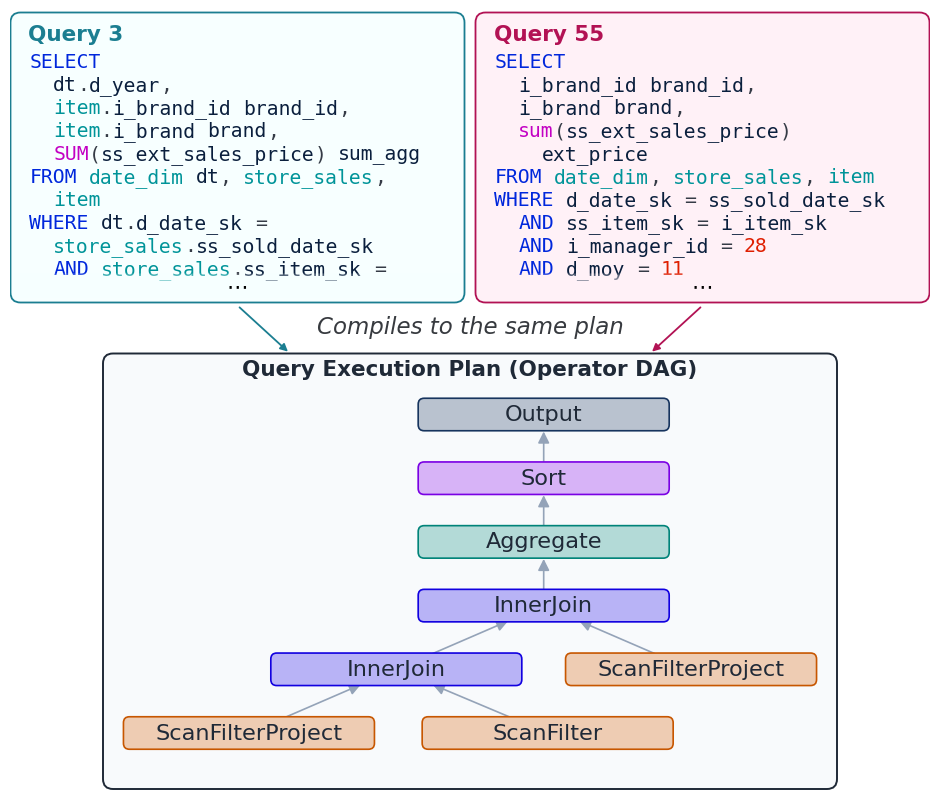

In [32]:

QUERY_A = "q3" # For every November across all years, break down total sales by brand for products from manufacturer #128, ranked year-by-year
QUERY_B = "q55" #For November 1999 specifically, rank brands by total sales for products under product-manager #28.

WORKLOAD = "tpcds"
OUT_NAME = "plan_collision_example"

make_plan_collision_figure(
    "q3", "q55",
    workload="tpcds", out_name="plan_collision_example",
    fig_w=9.2,
    sql_box_w=4.5,
    sql_box_gap=0.15,
    sql_font=14.2,
    sql_line_pitch=0.23,
    arrow_gap=0.55,
    plan_header_h=0.44,
    plan_caption_h=0.44,
    panel_w_floor=7.3,
    graph_side_pad=0.25,
    max_fill_scale=2.0,
    node_box_scale=0.95,
    graph_ranksep=0.15,
    graph_nodesep=0.25,
    converge_spread=1.8,
    sql_text_alpha=1.0,
    sql_fade_height=0.25,
    sql_title_font=15.5,
    panel_title_font=15.5,
    caption_font=16.5,
    color_vibrancy=1.9,
    node_fill_mute=0.7,
)

In [3]:

# Live slider UI for every size/layout/opacity/font/color knob exposed by
# make_plan_collision_figure. Drag a slider (updates on release) and the
# figure re-renders below. Once you like a look, click "Print current
# config" to get a ready-to-paste call.
import ipywidgets as widgets
from IPython.display import display, clear_output

_sk = dict(continuous_update=False, style={"description_width": "120px"},
           layout=widgets.Layout(width="420px"))

sliders = {
    "fig_w":            widgets.FloatSlider(value=8.6,  min=5.0, max=14.0, step=0.1,  description="fig_w", **_sk),
    "sql_box_w":        widgets.FloatSlider(value=3.9,  min=2.0, max=6.0,  step=0.1,  description="sql_box_w", **_sk),
    "sql_box_gap":      widgets.FloatSlider(value=0.15, min=0.0, max=1.0,  step=0.05, description="sql_box_gap", **_sk),
    "sql_font":         widgets.FloatSlider(value=9.6,  min=6.0, max=14.0, step=0.2,  description="sql_font", **_sk),
    "sql_line_pitch":   widgets.FloatSlider(value=0.14, min=0.10,max=0.30, step=0.01, description="sql_line_pitch", **_sk),
    "arrow_gap":        widgets.FloatSlider(value=0.55,  min=0.1, max=1.5,  step=0.05, description="arrow_gap", **_sk),
    "plan_header_h":    widgets.FloatSlider(value=0.44, min=0.3, max=1.2,  step=0.02, description="plan_header_h", **_sk),
    "plan_caption_h":   widgets.FloatSlider(value=0.44, min=0.2, max=1.0,  step=0.02, description="plan_caption_h", **_sk),
    "panel_w_floor":    widgets.FloatSlider(value=7.3,  min=3.0, max=14.0, step=0.1,  description="panel_w_floor", **_sk),
    "graph_side_pad":   widgets.FloatSlider(value=0.25,  min=0.05,max=2.0,  step=0.05, description="graph_side_pad", **_sk),
    "max_fill_scale":   widgets.FloatSlider(value=2.0,  min=1.0, max=5.0,  step=0.1,  description="max_fill_scale", **_sk),
    "node_box_scale":   widgets.FloatSlider(value=0.95,  min=0.3, max=4.0,  step=0.05, description="node_box_scale", **_sk),
    "graph_ranksep":    widgets.FloatSlider(value=0.15, min=0.05,max=1.5,  step=0.05, description="graph_ranksep", **_sk),
    "graph_nodesep":    widgets.FloatSlider(value=0.25, min=0.05,max=1.5,  step=0.05, description="graph_nodesep", **_sk),
    "converge_spread":  widgets.FloatSlider(value=1.8,  min=0.3, max=4.0,  step=0.1,  description="converge_spread", **_sk),
    "sql_text_alpha":   widgets.FloatSlider(value=1.0,  min=0.15,max=1.0,  step=0.05, description="sql_text_alpha", **_sk),
    "sql_fade_height":  widgets.FloatSlider(value=0.5,  min=0.0, max=3.0,  step=0.05, description="sql_fade_height", **_sk),
    "sql_title_font":   widgets.FloatSlider(value=15.5, min=8.0, max=20.0, step=0.5,  description="sql_title_font", **_sk),
    "panel_title_font": widgets.FloatSlider(value=13.5, min=6.0, max=18.0, step=0.5,  description="panel_title_font", **_sk),
    "caption_font":     widgets.FloatSlider(value=15, min=8.0, max=20.0, step=0.5,  description="caption_font", **_sk),
    "color_vibrancy":   widgets.FloatSlider(value=1.9, min=0.5, max=2.5,  step=0.05, description="color_vibrancy", **_sk),
    "node_fill_mute":   widgets.FloatSlider(value=0.7, min=0.0, max=0.95, step=0.05, description="node_fill_mute", **_sk),
}

query_a_box = widgets.Text(value=QUERY_A, description="query_a", style={"description_width": "120px"})
query_b_box = widgets.Text(value=QUERY_B, description="query_b", style={"description_width": "120px"})

out = widgets.Output()

def _render(query_a, query_b, **size_kwargs):
    with out:
        clear_output(wait=True)
        try:
            make_plan_collision_figure(
                query_a, query_b,
                workload=WORKLOAD,
                out_name=OUT_NAME,
                show=True,
                **size_kwargs,
            )
        except Exception as e:
            print(f"Error: {e}")

_controls = dict(sliders)
_controls["query_a"] = query_a_box
_controls["query_b"] = query_b_box
_live = widgets.interactive_output(_render, _controls)

print_btn = widgets.Button(description="Print current config", button_style="info")

def _print_config(_btn):
    print("make_plan_collision_figure(")
    print(f'    "{query_a_box.value}", "{query_b_box.value}",')
    print(f'    workload="{WORKLOAD}", out_name="{OUT_NAME}",')
    for k, s in sliders.items():
        print(f"    {k}={s.value!r},")
    print(")")

print_btn.on_click(_print_config)

controls_ui = widgets.VBox(
    [query_a_box, query_b_box, widgets.HTML("<hr>")] + list(sliders.values()) + [print_btn]
)
display(widgets.HBox([controls_ui, out]))
_live


Output()

In [27]:

from __future__ import annotations

import colorsys
import difflib
import re
import sys
import textwrap
from collections import defaultdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

_ANALYSIS_DIR = str(Path("./").resolve())   # workload_generation/analysis
if _ANALYSIS_DIR not in sys.path:
    sys.path.insert(0, _ANALYSIS_DIR)

from analysis import resolve_workload_path, load_plans_file                       # noqa: E402
from loader.workload_analysis import dags_from_plan_bundle, canonical_plan_graph_signature  # noqa: E402
from workload_generation.shared.sql_features import query_features                 # noqa: E402

import numpy as np
import networkx as nx
from networkx.drawing.nx_pydot import to_pydot
import pydot
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle

FIGURES_DIR = Path("./results/figures").resolve().parent

# ---------------------------------------------------------------------
# Palette (muted, paper-friendly)
# ---------------------------------------------------------------------
INK = "#1f2937"
MUTED = "#373a3f"
COL_A = "#4b7a83"   # muted teal
COL_B = "#a15574"   # muted mauve
COL_SHARED = "#1f2937"
BG_A = "#eef2f2"
BG_B = "#f5eef1"

ANSI_BLUE = "#0225C7"
ANSI_MAGENTA = "#B02DB0"
ANSI_GREEN = "#008400"
ANSI_RED = "#C91B00"
ANSI_CYAN = "#00868A"

KEYWORDS = {
    "select", "distinct", "as", "from", "where", "and", "or", "not", "in",
    "between", "exists", "group", "by", "order", "limit", "with", "on",
    "join", "inner", "left", "is", "null", "interval", "day", "asc", "desc",
    "case", "when", "then", "else", "end",
}
FUNCTIONS = {"count", "sum", "avg", "min", "max", "cast", "substr", "rank"}

CAT_COLOR = {
    "scan": "#b45309", "join": "#4338ca", "aggregate": "#0f766e",
    "sort": "#7e22ce", "output": "#334155", "project": "#475569",
    "filter": "#c2410c", "misc": "#78716c",
}
CAT_MERGE_LABEL = {
    "aggregate": "Aggregate",
    "sort": "Sort",
}

TOKEN_RE = re.compile(r"'[^']*'|\d+\.\d+|\d+|[A-Za-z_][A-Za-z0-9_]*|\s+|.", re.S)


def _categorize(op_name: str) -> str:
    if op_name in ("TableScan", "ScanFilter", "ScanFilterProject"):
        return "scan"
    if "Join" in op_name:
        return "join"
    if op_name == "Aggregate":
        return "aggregate"
    if op_name in ("TopN", "TopNPartial"):
        return "sort"
    if op_name == "Output":
        return "output"
    if op_name == "Project":
        return "project"
    if op_name in ("LocalExchange", "RemoteSource"):
        return "exchange"
    if "Filter" in op_name:
        return "filter"
    return "misc"


def _classify_token(tok: str, tables: set) -> Optional[str]:
    if tok[0] == "'":
        return ANSI_GREEN
    if re.match(r"^\d+(\.\d+)?$", tok):
        return ANSI_RED
    if tok.isspace():
        return None
    low = tok.lower()
    if low in KEYWORDS:
        return ANSI_BLUE
    if low in FUNCTIONS:
        return ANSI_MAGENTA
    if low in tables:
        return ANSI_CYAN
    if re.match(r"^[A-Za-z_][A-Za-z0-9_]*$", tok):
        return INK
    return MUTED


def _wrap_sql(sql_text: str, width: int, max_indent: int) -> List[str]:
    """Wrap each SQL line to at most `width` characters, keeping the
    original line's leading indent (capped at `max_indent`) on wrapped
    continuation lines so nested clauses stay visually nested rather
    than snapping back to the left margin."""
    out_lines = []
    for raw_line in sql_text.split("\n"):
        stripped = raw_line.rstrip()
        if not stripped.strip():
            continue
        indent = len(stripped) - len(stripped.lstrip(" "))
        capped = min(indent, max_indent)
        lead = " " * capped
        body = stripped[indent:]
        avail = max(1, width - capped)
        if len(body) <= avail:
            out_lines.append(lead + body)
        else:
            wrapped = textwrap.wrap(
                body, width=avail,
                initial_indent=lead, subsequent_indent=lead + "  ",
                break_long_words=False, break_on_hyphens=False,
            )
            out_lines.extend(wrapped)
    return out_lines


def _collapse_dag(dag: dict) -> Tuple[Dict[str, Tuple[str, str]], List[Tuple[str, str]]]:
    """Splice out exchange plumbing + merge same-category Aggregate/Sort
    chains. Returns (nodes: id -> (label, category), edges: [(parent, child)])."""
    nodes = dag["nodes"]
    children: Dict[str, List[str]] = defaultdict(list)
    parents: Dict[str, List[str]] = defaultdict(list)
    for e in dag["edges"]:
        p, c = e[0], e[1]
        children[p].append(c)
        parents[c].append(p)

    alive = set(nodes.keys())
    cat = {nid: _categorize(nodes[nid]["name"]) for nid in nodes}

    # 1. splice out pure-exchange nodes with exactly one parent and one child
    changed = True
    while changed:
        changed = False
        for nid in list(alive):
            if nid not in alive:
                continue
            if cat.get(nid) != "exchange":
                continue
            ps = [p for p in parents.get(nid, []) if p in alive]
            cs = [c for c in children.get(nid, []) if c in alive]
            if len(ps) == 1 and len(cs) == 1:
                p, c = ps[0], cs[0]
                children[p] = [c if x == nid else x for x in children[p]]
                parents[c] = [p if x == nid else x for x in parents[c]]
                alive.discard(nid)
                changed = True

    # 2. merge consecutive same-category aggregate/sort chains (1-in-1-out)
    def broad(nid):
        return cat[nid] if cat[nid] in ("aggregate", "sort") else None

    changed = True
    while changed:
        changed = False
        for nid in list(alive):
            if nid not in alive:
                continue
            bc = broad(nid)
            if bc is None:
                continue
            cs = [c for c in children.get(nid, []) if c in alive]
            if len(cs) != 1:
                continue
            c = cs[0]
            if broad(c) != bc:
                continue
            if len([p for p in parents.get(c, []) if p in alive]) != 1:
                continue
            grandchildren = [g for g in children.get(c, []) if g in alive]
            children[nid] = grandchildren
            for g in grandchildren:
                parents[g] = [nid if x == c else x for x in parents[g]]
            alive.discard(c)
            changed = True

    out_nodes: Dict[str, Tuple[str, str]] = {}
    for nid in alive:
        c = cat[nid]
        label = CAT_MERGE_LABEL.get(c, nodes[nid]["name"])
        out_nodes[nid] = (label, c)
    out_edges = [(p, c) for p in alive for c in children.get(p, []) if c in alive]
    return out_nodes, out_edges


def _table_jaccard(tables_a, tables_b) -> float:
    a, b = {t.lower() for t in tables_a}, {t.lower() for t in tables_b}
    if not a and not b:
        return 1.0
    return len(a & b) / len(a | b)


def list_collision_pairs(workload: str = "tpcds", workload_root: Optional[str] = None):
    import pandas as pd
    from itertools import combinations

    wpath = (resolve_workload_path(workload, workload_root=workload_root)
             if workload_root else resolve_workload_path(workload))
    bundle = load_plans_file(wpath)
    if bundle is None:
        raise ValueError(f"No plans.json for workload '{workload}' -- capture plans first.")
    dags = dags_from_plan_bundle(bundle)
    plans = bundle["plans"]

    sig = {q: canonical_plan_graph_signature(dags[q]) for q in dags}
    groups: Dict[str, List[str]] = defaultdict(list)
    for q, s in sig.items():
        groups[s].append(q)

    feat = {q: query_features(plans[q]["sql"]) for q in dags}
    rows = []
    for s, qs in groups.items():
        if len(qs) < 2:
            continue
        for qa, qb in combinations(sorted(qs), 2):
            tj = _table_jaccard(feat[qa].get("tables", []), feat[qb].get("tables", []))
            ts = difflib.SequenceMatcher(
                None,
                " ".join(plans[qa]["sql"].lower().split()),
                " ".join(plans[qb]["sql"].lower().split()),
            ).ratio()
            rows.append({
                "query_a": qa, "query_b": qb,
                "table_jaccard": round(tj, 3), "text_similarity": round(ts, 3),
                "surprise_score": round(((1 - tj) + (1 - ts)) / 2, 3),
                "full_plan_nodes": len(dags[qa]["nodes"]),
            })
    return pd.DataFrame(rows).sort_values("surprise_score", ascending=False).reset_index(drop=True)


def make_plan_collision_figure(
    query_a: str,
    query_b: str,
    *,
    workload: str = "tpcds",
    workload_root: Optional[str] = None,
    preview_lines: int = 10,
    out_name: str = "plan_collision_example",
    out_dir: Optional[Path] = None,
    title: Optional[str] = None,
    label_a: Optional[str] = None,
    label_b: Optional[str] = None,
    show: bool = True,
    # -----------------------------------------------------------
    # Size/layout knobs -- override any of these instead of hand-
    # editing constants in the function body. See the slider cell
    # below for a live UI over all of these.
    # -----------------------------------------------------------
    fig_w: float = 7.5,
    sql_box_w: float = 3.5,
    sql_box_gap: float = 0.15,
    sql_font: float = 8.6,
    sql_line_pitch: float = 0.15,
    arrow_gap: float = 0.5,
    plan_header_h: float = 0.62,
    plan_caption_h: float = 0.48,
    panel_w_floor: float = 5.6,
    graph_side_pad: float = 0.4,
    max_fill_scale: float = 2.0,
    node_box_scale: float = 1.0,
    graph_ranksep: float = 0.25,
    graph_nodesep: float = 0.25,
    converge_spread: float = 1.4,
    # -----------------------------------------------------------
    # SQL text opacity + the remaining (non-node) font sizes.
    # -----------------------------------------------------------
    sql_text_alpha: float = 1.0,
    sql_fade_height: float = 0.9,
    sql_title_font: float = 12.0,
    panel_title_font: float = 10.0,
    caption_font: float = 13.0,
    # -----------------------------------------------------------
    # Color intensity -- color_vibrancy boosts saturation on the SQL
    # syntax-highlight colors, the two query accent colors (and their
    # backgrounds), and the DAG node category colors. node_fill_mute
    # is how much white gets blended into a node box's fill (lower =
    # more saturated fill); the node's border always stays full color.
    # -----------------------------------------------------------
    color_vibrancy: float = 1.35,
    node_fill_mute: float = 0.55,
):
    """Build the headline "two queries, one plan" figure and save it as
    <out_dir>/<out_name>.png and .pdf. Returns the saved PNG path.

    Raises ValueError if query_a/query_b don't share a plans.json entry or
    don't actually compile to the same plan (canonical_plan_graph_signature).
    """
    wpath = (resolve_workload_path(workload, workload_root=workload_root)
             if workload_root else resolve_workload_path(workload))
    bundle = load_plans_file(wpath)
    if bundle is None:
        raise ValueError(f"No plans.json for workload '{workload}' -- capture plans first.")
    dags = dags_from_plan_bundle(bundle)
    if query_a not in dags or query_b not in dags:
        missing = [q for q in (query_a, query_b) if q not in dags]
        raise ValueError(f"Query name(s) not found in {workload}'s plans.json: {missing}")

    dag_a, dag_b = dags[query_a], dags[query_b]
    if canonical_plan_graph_signature(dag_a) != canonical_plan_graph_signature(dag_b):
        raise ValueError(
            f"{query_a} and {query_b} do NOT compile to the same Trino plan "
            "(canonical_plan_graph_signature differs) -- pick a genuine collision pair."
        )
    full_n_nodes, full_n_edges = len(dag_a["nodes"]), len(dag_a["edges"])

    plans = bundle["plans"]
    sql_a, sql_b = plans[query_a]["sql"], plans[query_b]["sql"]
    feat_a, feat_b = query_features(sql_a), query_features(sql_b)
    tables_a, tables_b = feat_a.get("tables", []), feat_b.get("tables", [])
    tbl_jaccard = _table_jaccard(tables_a, tables_b)
    text_sim = difflib.SequenceMatcher(
        None, " ".join(sql_a.lower().split()), " ".join(sql_b.lower().split())
    ).ratio()
    all_tables = {t.lower() for t in tables_a} | {t.lower() for t in tables_b}

    def classify(tok):
        return _classify_token(tok, all_tables)

    def _boost(hex_color, factor):
        """Push a color's saturation up by `factor` (1.0 = unchanged),
        clamped so it never blows out to a garish oversaturated result."""
        r, g, b = to_rgba(hex_color)[:3]
        h, s, v = colorsys.rgb_to_hsv(r, g, b)
        s = min(1.0, s * factor)
        v = min(1.0, v * (1.0 + (factor - 1.0) * 0.12))
        return colorsys.hsv_to_rgb(h, s, v)

    col_a_v = _boost(COL_A, color_vibrancy)
    col_b_v = _boost(COL_B, color_vibrancy)
    bg_a_v = _boost(BG_A, color_vibrancy)
    bg_b_v = _boost(BG_B, color_vibrancy)

    n_lines = preview_lines

    # ---------------------------------------------------------------
    # Collapsed plan DAG -> Graphviz `dot` layout
    # ---------------------------------------------------------------
    node_defs, edge_defs = _collapse_dag(dag_a)
    G = nx.DiGraph()
    G.add_nodes_from(node_defs)
    G.add_edges_from(edge_defs)

    P = to_pydot(G)
    P.set_rankdir("TB")
    P.set_ranksep(str(graph_ranksep))
    P.set_nodesep(str(graph_nodesep))
    P.set_splines("spline")
    P.set_prog("dot")
    dot_src = P.create_dot().decode("utf-8")
    (pg,) = pydot.graph_from_dot_data(dot_src)
    raw_pos = {}
    for n in pg.get_nodes():
        nm = n.get_name().strip('"')
        if nm in G.nodes and n.get_pos():
            x, y = n.get_pos().strip('"').split(",")
            raw_pos[nm] = (float(x), float(y))
    xs = [p[0] for p in raw_pos.values()]
    ys = [p[1] for p in raw_pos.values()]
    X0, X1 = min(xs), max(xs)
    Y0, Y1 = min(ys), max(ys)

    # auto-scale graph panel to the collapsed node/rank bounding box, clamped
    # to a sane paper-figure range so this "just works" for small or large
    # pairs without any manual tuning per query
    NATURAL_GRAPH_W = min(9.2, max(0.0025, 0.0055 * (X1 - X0) + 1.6))
    NATURAL_GRAPH_H = min(6.0, max(0.002, 0.0055 * (Y1 - Y0) + 0.6))

    # The panel has a minimum width (panel_w_floor) regardless of how small
    # the collapsed DAG is, so a small DAG at its "natural" size would leave
    # a big empty margin inside the panel. Instead, zoom the whole diagram
    # (positions, node boxes, fonts, arrows) up -- uniformly, preserving its
    # aspect ratio -- so it actually fills the panel it's drawn in.
    # node_box_scale is an independent knob on top of that: it only grows
    # the node boxes/fonts/arrows, not the panel or the layout spacing.
    fill_scale = min(max_fill_scale, max(1.0, (panel_w_floor - graph_side_pad) / NATURAL_GRAPH_W))
    GRAPH_W = NATURAL_GRAPH_W * fill_scale
    GRAPH_H = NATURAL_GRAPH_H * fill_scale
    NODE_R = 0.19

    # ---------------------------------------------------------------
    # Figure geometry (derived additively so nothing can overlap)
    # ---------------------------------------------------------------
    FIG_W = fig_w
    TOP_MARGIN = 0.05
    SQL_FONT = sql_font
    LINE_PITCH = sql_line_pitch
    SQL_HEADER_H = 0.38
    SQL_PAD_BOTTOM = 0.18
    BOX_H = SQL_HEADER_H + n_lines * LINE_PITCH + SQL_PAD_BOTTOM
    ARROW_GAP = arrow_gap

    PLAN_HEADER_H = plan_header_h
    PLAN_CAPTION_H = plan_caption_h
    PLAN_BOX_H = PLAN_HEADER_H + GRAPH_H + PLAN_CAPTION_H + 0.15
    BOTTOM_MARGIN = 0.07

    FIG_H = TOP_MARGIN + BOX_H + ARROW_GAP + PLAN_BOX_H + BOTTOM_MARGIN

    fig = plt.figure(figsize=(FIG_W, FIG_H))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, FIG_W)
    ax.set_ylim(0, FIG_H)
    ax.axis("off")

    # ---------------------------------------------------------------
    # SQL preview text -- wrapped to the *actual* pixel width of the
    # SQL box (sql_box_w at the current sql_font), not a fixed character
    # count, so text can never spill past the box edge no matter how
    # sql_box_w/sql_font are set. Continuation lines keep the original
    # line's indent so nested clauses still read as nested.
    # ---------------------------------------------------------------
    TEXT_PAD = 0.17  # matches the left inset used when drawing SQL tokens below
    _probe = ax.text(-100, -100, "M" * 40, fontsize=SQL_FONT, family="monospace")
    fig.canvas.draw()
    _bbox = _probe.get_window_extent(renderer=fig.canvas.get_renderer())
    _bbox_data = ax.transData.inverted().transform(_bbox)
    CHAR_W = (_bbox_data[1][0] - _bbox_data[0][0]) / 40.0
    _probe.remove()

    max_text_w = max(0.5, sql_box_w - 2 * TEXT_PAD)
    wrap_width = max(10, int(max_text_w / CHAR_W * 0.97))
    max_indent = min(6, max(0, wrap_width // 4))

    lines_a_full = _wrap_sql(sql_a, wrap_width, max_indent)
    lines_b_full = _wrap_sql(sql_b, wrap_width, max_indent)
    lines_a = lines_a_full[:preview_lines]
    lines_b = lines_b_full[:preview_lines]
    trunc_a = len(lines_a_full) > preview_lines
    trunc_b = len(lines_b_full) > preview_lines

    # ---------------------------------------------------------------
    # Title / claim
    # ---------------------------------------------------------------
    title = title or "Two TPC-DS queries, One Trino plan"
    label_a = label_a or f"Query {query_a[1:]}"
    label_b = label_b or f"Query {query_b[1:]}"

    # ---------------------------------------------------------------
    # SQL boxes
    # ---------------------------------------------------------------
    BOX_TOP = FIG_H - TOP_MARGIN
    BOX_W = sql_box_w
    GAP = sql_box_gap
    LEFT_X = (FIG_W - 2 * BOX_W - GAP) / 2
    RIGHT_X = LEFT_X + BOX_W + GAP

    FADE_H = sql_fade_height

    def add_fade(x, y_bottom, width, height, color):
        rgb = to_rgba(color)[:3]
        grad = np.zeros((256, 1, 4))
        grad[:, 0, 0], grad[:, 0, 1], grad[:, 0, 2] = rgb
        grad[:, 0, 3] = np.linspace(1, 0, 256) ** 0.5
        ax.imshow(grad, extent=(x, x + width, y_bottom, y_bottom + height),
                  origin="lower", aspect="auto", zorder=4, interpolation="bilinear")

    def sql_box(x, title_, subtitle_, lines, color, bg, truncated):
        box = FancyBboxPatch(
            (x, BOX_TOP - BOX_H), BOX_W, BOX_H,
            boxstyle="round,pad=0.02,rounding_size=0.1",
            linewidth=1.3, edgecolor=color, facecolor=bg, zorder=2,
        )
        ax.add_patch(box)
        ax.text(x + 0.16, BOX_TOP - 0.10, title_, fontsize=sql_title_font, fontweight="bold",
                 color=color, family="sans-serif", va="top")
        y = BOX_TOP - SQL_HEADER_H
        text_x0 = x + TEXT_PAD
        for ln in lines:
            xc = text_x0
            for tok in TOKEN_RE.findall(ln):
                col = classify(tok)
                if col is not None and not tok.isspace():
                    ax.text(xc, y, tok, fontsize=SQL_FONT, color=_boost(col, color_vibrancy),
                             family="monospace", va="top", ha="left", zorder=3,
                             alpha=sql_text_alpha)
                xc += CHAR_W * len(tok)
            y -= LINE_PITCH
        if truncated:
            add_fade(x + 0.02, BOX_TOP - BOX_H + 0.02, BOX_W - 0.04, FADE_H, bg)
            ax.text(x + BOX_W / 2, BOX_TOP - BOX_H + FADE_H * 0.55, "⋯",
                     ha="center", va="center", fontsize=sql_title_font, color="black",
                     family="sans-serif", zorder=5)
        return x + BOX_W / 2, BOX_TOP - BOX_H

    qa_bottom_x, qa_bottom_y = sql_box(
        LEFT_X, label_a, "verbatim SQL preview", lines_a, col_a_v, bg_a_v, trunc_a,
    )
    qb_bottom_x, qb_bottom_y = sql_box(
        RIGHT_X, label_b, "verbatim SQL preview", lines_b, col_b_v, bg_b_v, trunc_b,
    )

    # ---------------------------------------------------------------
    # Plan panel
    # ---------------------------------------------------------------
    PLAN_BOX_W = max(panel_w_floor, GRAPH_W + graph_side_pad)
    plan_box_x = FIG_W / 2 - PLAN_BOX_W / 2
    plan_box_bottom = BOTTOM_MARGIN
    plan_box_top = plan_box_bottom + PLAN_BOX_H
    plan_box = FancyBboxPatch(
        (plan_box_x, plan_box_bottom), PLAN_BOX_W, PLAN_BOX_H,
        boxstyle="round,pad=0.02,rounding_size=0.1",
        linewidth=1.4, edgecolor=COL_SHARED, facecolor="#f8fafc", zorder=2,
    )
    ax.add_patch(plan_box)
    ax.text(FIG_W / 2, plan_box_top - 0.2,
             "Query Execution Plan (Operator DAG)",
             ha="center", fontsize=panel_title_font, fontweight="bold", color=COL_SHARED, family="sans-serif")

    graph_left = plan_box_x + (PLAN_BOX_W - GRAPH_W) / 2
    graph_bottom = plan_box_bottom + PLAN_CAPTION_H + 0.1

    def remap(nid):
        x, y = raw_pos[nid]
        denom_x = (X1 - X0) or 1.0
        denom_y = (Y1 - Y0) or 1.0
        rx = (x - X0) / denom_x * GRAPH_W + graph_left
        ry = (y - Y0) / denom_y * GRAPH_H + graph_bottom
        return rx, ry

    pos_in = {nid: remap(nid) for nid in raw_pos}

    NODE_W, NODE_H = 1.3 * fill_scale * node_box_scale, 0.15 * fill_scale * node_box_scale
    NODE_FONT = 8.5 * fill_scale * node_box_scale

    def _rect_edge_point(cx, cy, w, h, tx, ty):
        """Point where the segment from (cx,cy) to (tx,ty) exits the w x h
        rectangle centered at (cx,cy) -- exact for any approach angle,
        unlike a fixed point-shrink which only suits round nodes."""
        dx, dy = tx - cx, ty - cy
        if dx == 0 and dy == 0:
            return (cx, cy)
        candidates = []
        if dx != 0:
            candidates.append((w / 2) / abs(dx))
        if dy != 0:
            candidates.append((h / 2) / abs(dy))
        t = min(candidates)
        return (cx + t * dx, cy + t * dy)

    ARROW_GAP_PT = 2
    for parent, child in G.edges():
        p_pos, c_pos = pos_in[parent], pos_in[child]
        p_edge = _rect_edge_point(*p_pos, NODE_W, NODE_H, *c_pos)
        c_edge = _rect_edge_point(*c_pos, NODE_W, NODE_H, *p_pos)
        arr = FancyArrowPatch(
            c_edge, p_edge, arrowstyle="-|>", mutation_scale=9 * fill_scale * node_box_scale, linewidth=1.2,
            color="#94a3b8", connectionstyle="arc3,rad=0.0", zorder=3,
            shrinkA=ARROW_GAP_PT, shrinkB=ARROW_GAP_PT,
        )
        ax.add_patch(arr)

    def _mute(color, amount=0.78):
        """Blend a color toward white by `amount` (0 = unchanged, 1 = white)."""
        r, g, b = to_rgba(color)[:3]
        return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount)

    for nid, (cx, cy) in pos_in.items():
        label, cat = node_defs[nid]
        color = _boost(CAT_COLOR[cat], color_vibrancy)
        ax.add_patch(FancyBboxPatch(
            (cx - NODE_W / 2, cy - NODE_H / 2), NODE_W, NODE_H,
            boxstyle="round,pad=0.02,rounding_size=0.06",
            facecolor=_mute(color, node_fill_mute), edgecolor=color, linewidth=1.2, zorder=5))
        ax.text(cx, cy, label, ha="center", va="center",
                 fontsize=NODE_FONT, color=INK, family="sans-serif", zorder=6)

    # ---------------------------------------------------------------
    # Convergent arrows: SQL -> shared plan
    # ---------------------------------------------------------------
    CONVERGE_X = FIG_W / 2
    CONVERGE_Y = plan_box_top + 0.02
    CONVERGE_SPREAD = converge_spread   # half-distance between the two landing points
    for (x0, y0), color, cx in [
        ((qa_bottom_x, qa_bottom_y), col_a_v, CONVERGE_X - CONVERGE_SPREAD),
        ((qb_bottom_x, qb_bottom_y), col_b_v, CONVERGE_X + CONVERGE_SPREAD),
    ]:
        arr = FancyArrowPatch(
            (x0, y0 - 0.05), (cx, CONVERGE_Y),
            arrowstyle="-|>", mutation_scale=11, linewidth=1.3,
            color=color, connectionstyle="arc3,rad=0.0", zorder=6,
        )
        ax.add_patch(arr)
    ax.text(CONVERGE_X, (min(qa_bottom_y, qb_bottom_y) + CONVERGE_Y) / 2, "Compiles to the same plan",
             ha="center", va="center", fontsize=caption_font, color=MUTED, family="sans-serif",
             style="italic", zorder=7,
             )

    out_dir = Path(out_dir) if out_dir else FIGURES_DIR
    out_dir.mkdir(parents=True, exist_ok=True)
    out_png = out_dir / f"{out_name}.png"
    out_pdf = out_dir / f"{out_name}.pdf"
    fig.savefig(out_png)
    fig.savefig(out_pdf)

    if show:
        plt.show()
    else:
        plt.close(fig)


/tmp/ipykernel_696622/2293143004.py:360: DeprecationWarning: nx.nx_pydot.to_pydot depends on the pydot package, which has known issues and is not actively maintained.

See https://github.com/networkx/networkx/issues/5723
  P = to_pydot(G)


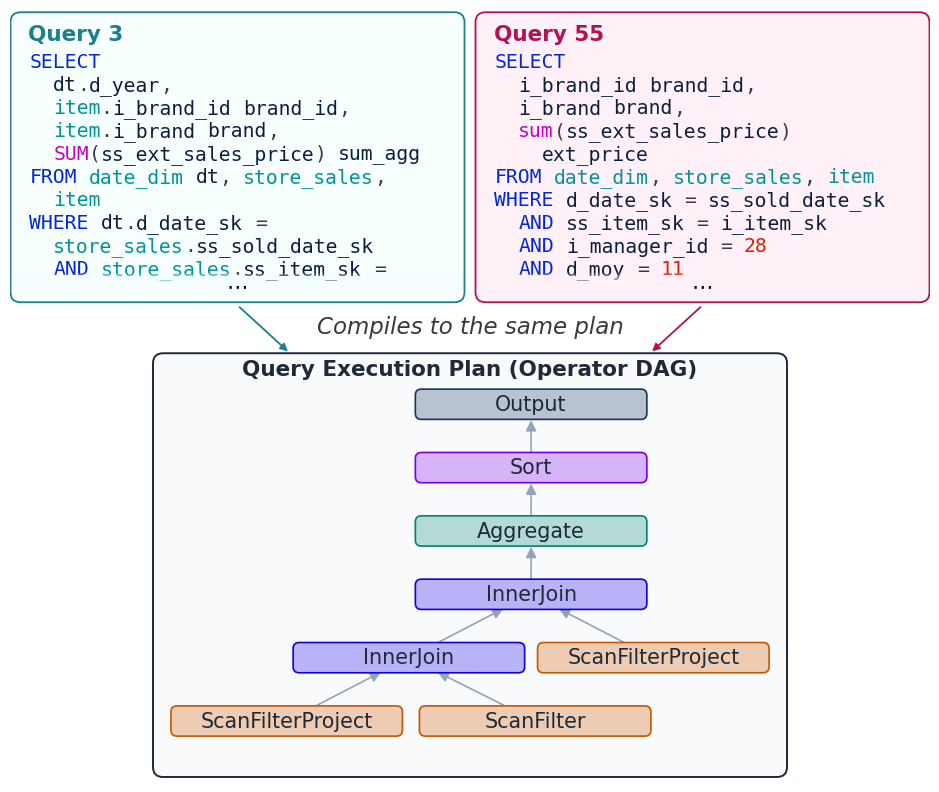

In [28]:

QUERY_A = "q3" # For every November across all years, break down total sales by brand for products from manufacturer #128, ranked year-by-year
QUERY_B = "q55" #For November 1999 specifically, rank brands by total sales for products under product-manager #28.

WORKLOAD = "tpcds"
OUT_NAME = "plan_collision_example"

make_plan_collision_figure(
    "q3", "q55",
    workload="tpcds", out_name="plan_collision_example",
    fig_w=9.2,
    sql_box_w=4.5,
    sql_box_gap=0.15,
    sql_font=14.2,
    sql_line_pitch=0.23,
    arrow_gap=0.55,
    plan_header_h=0.44,
    plan_caption_h=0.44,
    panel_w_floor=6.3,
    graph_side_pad=0.25,
    max_fill_scale=1.75,
    node_box_scale=1,
    graph_ranksep=0.05,
    graph_nodesep=0.05,
    converge_spread=1.8,
    sql_text_alpha=1.0,
    sql_fade_height=0.25,
    sql_title_font=15.5,
    panel_title_font=15.5,
    caption_font=16.5,
    color_vibrancy=1.9,
    node_fill_mute=0.7,
)

In [20]:

# Live slider UI for every size/layout/opacity/font/color knob exposed by
# make_plan_collision_figure. Drag a slider (updates on release) and the
# figure re-renders below. Once you like a look, click "Print current
# config" to get a ready-to-paste call.
import ipywidgets as widgets
from IPython.display import display, clear_output

_sk = dict(continuous_update=False, style={"description_width": "120px"},
           layout=widgets.Layout(width="420px"))

sliders = {
    "fig_w":            widgets.FloatSlider(value=8.6,  min=5.0, max=14.0, step=0.1,  description="fig_w", **_sk),
    "sql_box_w":        widgets.FloatSlider(value=3.9,  min=2.0, max=6.0,  step=0.1,  description="sql_box_w", **_sk),
    "sql_box_gap":      widgets.FloatSlider(value=0.15, min=0.0, max=1.0,  step=0.05, description="sql_box_gap", **_sk),
    "sql_font":         widgets.FloatSlider(value=9.6,  min=6.0, max=14.0, step=0.2,  description="sql_font", **_sk),
    "sql_line_pitch":   widgets.FloatSlider(value=0.14, min=0.10,max=0.30, step=0.01, description="sql_line_pitch", **_sk),
    "arrow_gap":        widgets.FloatSlider(value=0.55,  min=0.1, max=1.5,  step=0.05, description="arrow_gap", **_sk),
    "plan_header_h":    widgets.FloatSlider(value=0.44, min=0.3, max=1.2,  step=0.02, description="plan_header_h", **_sk),
    "plan_caption_h":   widgets.FloatSlider(value=0.44, min=0.2, max=1.0,  step=0.02, description="plan_caption_h", **_sk),
    "panel_w_floor":    widgets.FloatSlider(value=7.3,  min=3.0, max=14.0, step=0.1,  description="panel_w_floor", **_sk),
    "graph_side_pad":   widgets.FloatSlider(value=0.25,  min=0.05,max=2.0,  step=0.05, description="graph_side_pad", **_sk),
    "max_fill_scale":   widgets.FloatSlider(value=2.0,  min=1.0, max=5.0,  step=0.1,  description="max_fill_scale", **_sk),
    "node_box_scale":   widgets.FloatSlider(value=0.95,  min=0.3, max=4.0,  step=0.05, description="node_box_scale", **_sk),
    "graph_ranksep":    widgets.FloatSlider(value=0.15, min=0.05,max=1.5,  step=0.05, description="graph_ranksep", **_sk),
    "graph_nodesep":    widgets.FloatSlider(value=0.25, min=0.05,max=1.5,  step=0.05, description="graph_nodesep", **_sk),
    "converge_spread":  widgets.FloatSlider(value=1.8,  min=0.3, max=4.0,  step=0.1,  description="converge_spread", **_sk),
    "sql_text_alpha":   widgets.FloatSlider(value=1.0,  min=0.15,max=1.0,  step=0.05, description="sql_text_alpha", **_sk),
    "sql_fade_height":  widgets.FloatSlider(value=0.5,  min=0.0, max=3.0,  step=0.05, description="sql_fade_height", **_sk),
    "sql_title_font":   widgets.FloatSlider(value=15.5, min=8.0, max=20.0, step=0.5,  description="sql_title_font", **_sk),
    "panel_title_font": widgets.FloatSlider(value=13.5, min=6.0, max=18.0, step=0.5,  description="panel_title_font", **_sk),
    "caption_font":     widgets.FloatSlider(value=15, min=8.0, max=20.0, step=0.5,  description="caption_font", **_sk),
    "color_vibrancy":   widgets.FloatSlider(value=1.9, min=0.5, max=2.5,  step=0.05, description="color_vibrancy", **_sk),
    "node_fill_mute":   widgets.FloatSlider(value=0.7, min=0.0, max=0.95, step=0.05, description="node_fill_mute", **_sk),
}

query_a_box = widgets.Text(value=QUERY_A, description="query_a", style={"description_width": "120px"})
query_b_box = widgets.Text(value=QUERY_B, description="query_b", style={"description_width": "120px"})

out = widgets.Output()

def _render(query_a, query_b, **size_kwargs):
    with out:
        clear_output(wait=True)
        try:
            make_plan_collision_figure(
                query_a, query_b,
                workload=WORKLOAD,
                out_name=OUT_NAME,
                show=True,
                **size_kwargs,
            )
        except Exception as e:
            print(f"Error: {e}")

_controls = dict(sliders)
_controls["query_a"] = query_a_box
_controls["query_b"] = query_b_box
_live = widgets.interactive_output(_render, _controls)

print_btn = widgets.Button(description="Print current config", button_style="info")

def _print_config(_btn):
    print("make_plan_collision_figure(")
    print(f'    "{query_a_box.value}", "{query_b_box.value}",')
    print(f'    workload="{WORKLOAD}", out_name="{OUT_NAME}",')
    for k, s in sliders.items():
        print(f"    {k}={s.value!r},")
    print(")")

print_btn.on_click(_print_config)

controls_ui = widgets.VBox(
    [query_a_box, query_b_box, widgets.HTML("<hr>")] + list(sliders.values()) + [print_btn]
)
display(widgets.HBox([controls_ui, out]))
_live


Output()